`Machine Learning Clasificación y Regresión | Analía Elizabeth Gomory | Salta - 4400 - Argentina | 2025`

**by Analía Elizabeth Gomory**

* ae.gomory@gmail.com

* http://www.linkedin.com/in/elizabeth-gomory-9240b1217

* https://ae-gomory.itch.io

* https://github.com/ElizabethGomory

* https://www.credly.com/users/analia-gomory

* https://orcid.org/0009-0003-0498-7658

## Importación de librerías y Archivos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn import svm
from sklearn.svm import SVR
from sklearn.decomposition import PCA

import openpyxl as load_workbook
from pathlib import Path
import io
import sys
import os
sys.path.append(r'claseinfodf_2')
df = pd.read_csv("AmesHousing.csv")


## Normalización de datos

In [5]:
df.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500
9,10,527162130,60,RL,60.0,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,189000


In [6]:
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]  
missing_data

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Finish      159
Garage Yr Blt      159
Garage Qual        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
Garage Cars          1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Garage Area          1
dtype: int64

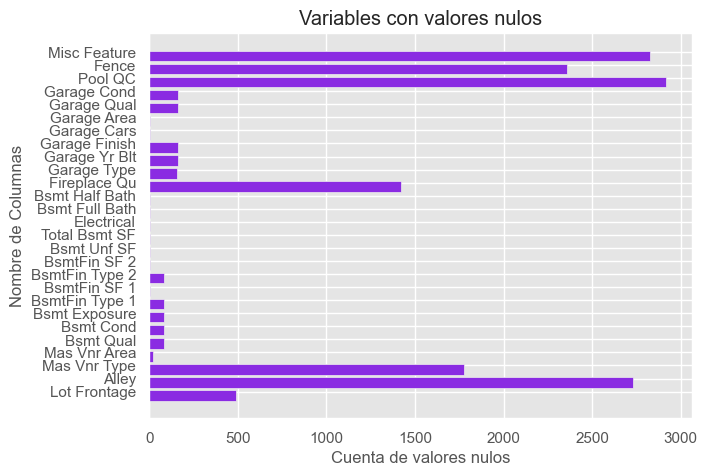

In [7]:
sns.set(font_scale=1)
matplotlib.style.use('ggplot')
labels = []
values = []
for col in df.columns[df.isnull().any()]:
    labels.append(col)
    values.append(df[col].isnull().sum())
ind = np.arange(len(labels))
ind
width=0.6
fig, ax = plt.subplots(figsize=(7,5))
rects = ax.barh(ind, np.array(values), color='blueviolet')
ax.set_yticks(ind+((width)/2.))
ax.set_yticklabels(labels, rotation='horizontal')
ax.set_xlabel("Cuenta de valores nulos")
ax.set_ylabel("Nombre de Columnas")
ax.set_title("Variables con valores nulos");

Limpieza de datos

In [8]:
# Decidí eliminar solo las columnas con más del 35% de valores nulos, de lo contrario, me quedaría sin datos a entrenar
threshold = 0.35 * len(df)
columns_drop = missing_data[missing_data > threshold].index.tolist()
df_cleaned = df.drop(columns=columns_drop)

In [9]:
df_cleaned = df_cleaned.dropna()
df_cleaned = df.drop(columns=df.select_dtypes(include=['object', 'float64']).columns)
df_cleaned.shape

(2930, 28)

In [10]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Order            2930 non-null   int64
 1   PID              2930 non-null   int64
 2   MS SubClass      2930 non-null   int64
 3   Lot Area         2930 non-null   int64
 4   Overall Qual     2930 non-null   int64
 5   Overall Cond     2930 non-null   int64
 6   Year Built       2930 non-null   int64
 7   Year Remod/Add   2930 non-null   int64
 8   1st Flr SF       2930 non-null   int64
 9   2nd Flr SF       2930 non-null   int64
 10  Low Qual Fin SF  2930 non-null   int64
 11  Gr Liv Area      2930 non-null   int64
 12  Full Bath        2930 non-null   int64
 13  Half Bath        2930 non-null   int64
 14  Bedroom AbvGr    2930 non-null   int64
 15  Kitchen AbvGr    2930 non-null   int64
 16  TotRms AbvGrd    2930 non-null   int64
 17  Fireplaces       2930 non-null   int64
 18  Wood Dec

In [12]:
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns
df_cleaned[num_cols] = df_cleaned[num_cols].apply(lambda x: x.fillna(x.mean()))
print("Valores faltantes restantes por columna (debe ser 0):")
print(df_cleaned[num_cols].isnull().sum().head(5))


Valores faltantes restantes por columna (debe ser 0):
Order           0
PID             0
MS SubClass     0
Lot Area        0
Overall Qual    0
dtype: int64


## Selección de Variables para PCA

In [14]:
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
features = [c for c in numeric_cols if c not in ['SalePrice','Order','PID']]
print("Número de variables numéricas seleccionadas:", len(features))

Número de variables numéricas seleccionadas: 25


Normalización de datos con StandardScaler

In [16]:
scaler = StandardScaler()
X = df_cleaned[features].values
X_scaled = scaler.fit_transform(X)
print("Media (aprox) Escalado:", np.round(X_scaled.mean(axis=0)[:3],3))
print("Varianza (aprox) Escalado:", np.round(X_scaled.std(axis=0)[:3],3))

Media (aprox) Escalado: [-0.  0. -0.]
Varianza (aprox) Escalado: [1. 1. 1.]


In [19]:
corr_with_price = df_cleaned[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
print("Variables Correlacionadas con SalePrice:")
print(corr_with_price.head(6))

Variables Correlacionadas con SalePrice:
SalePrice       1.000000
Overall Qual    0.799262
Gr Liv Area     0.706780
1st Flr SF      0.621676
Year Built      0.558426
Full Bath       0.545604
Name: SalePrice, dtype: float64


Aplicación de PCA 

In [24]:
pca = PCA(n_components=len(features))
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

print("Varianza explicada por los primeros componentes:")
for i, v in enumerate(explained_var[:6], start=1):
    print(f"  PC{i}: {v:.3f}, acumulada: {cum_var[i-1]:.3f}")
    
explica_set= np.argmax(cum_var >= 0.90) + 1
print("Componentes necesarios para explicar ≥90% de varianza:", explica_set)


Varianza explicada por los primeros componentes:
  PC1: 0.197, acumulada: 0.197
  PC2: 0.097, acumulada: 0.294
  PC3: 0.076, acumulada: 0.370
  PC4: 0.057, acumulada: 0.426
  PC5: 0.047, acumulada: 0.473
  PC6: 0.045, acumulada: 0.518
Componentes necesarios para explicar ≥90% de varianza: 17


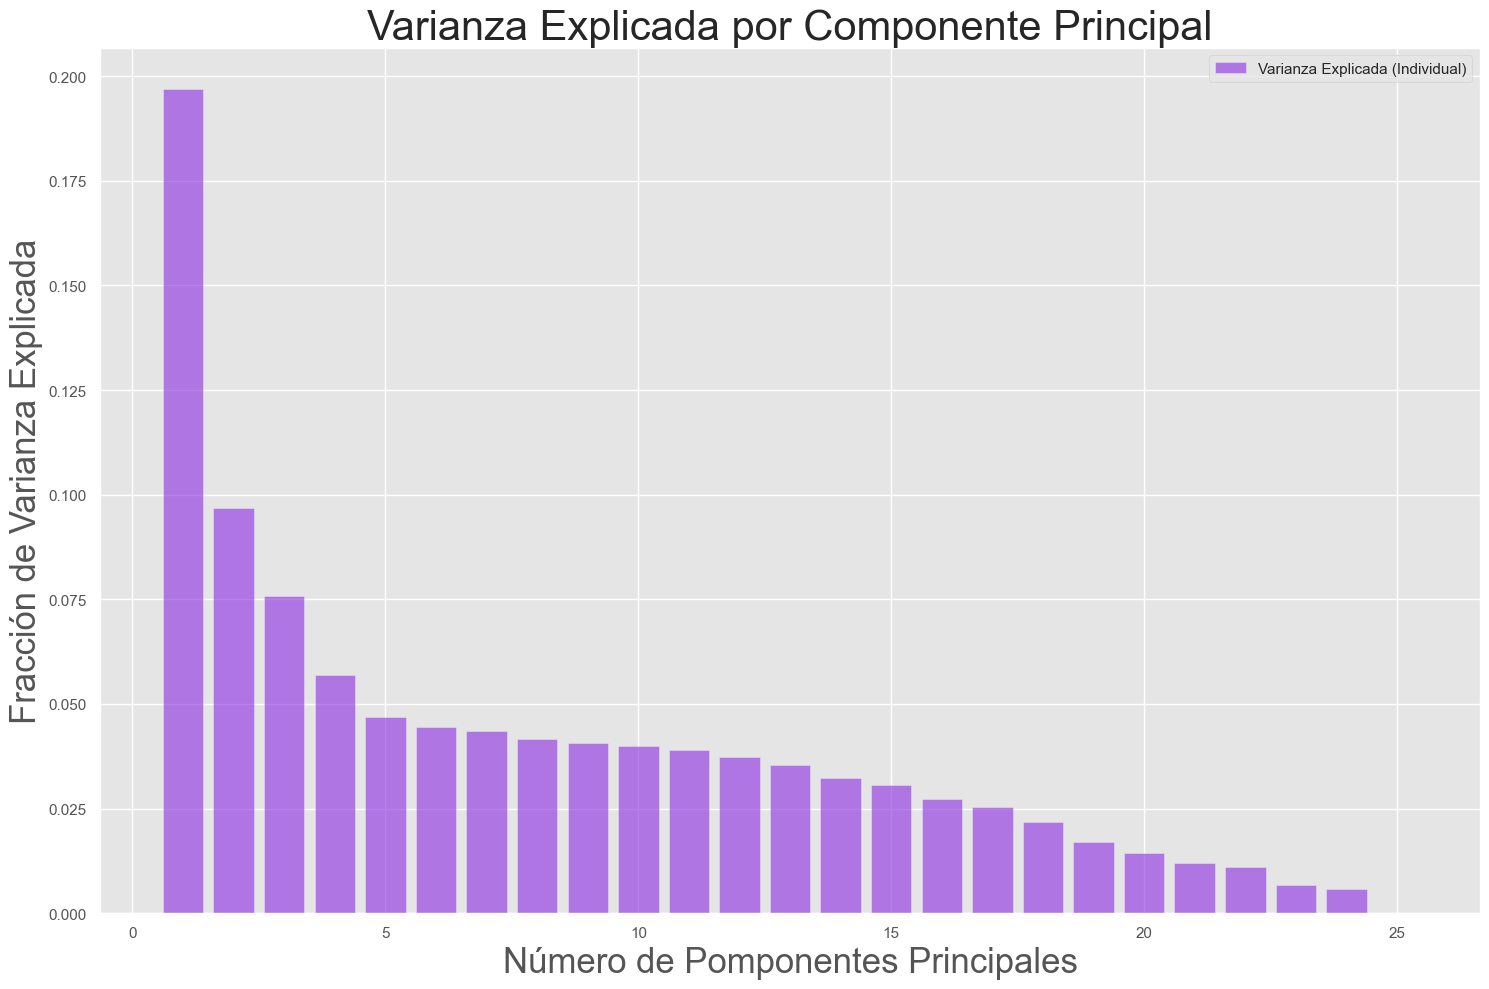

In [ ]:
plt.figure(figsize=(15, 10))
plt.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.6, label='Varianza Explicada (Individual)', color='blueviolet')
plt.title('Varianza Explicada por Componente Principal', size=30)
plt.xlabel('Número de Pomponentes Principales', size=25)
plt.ylabel('Fracción de Varianza Explicada', size=25)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

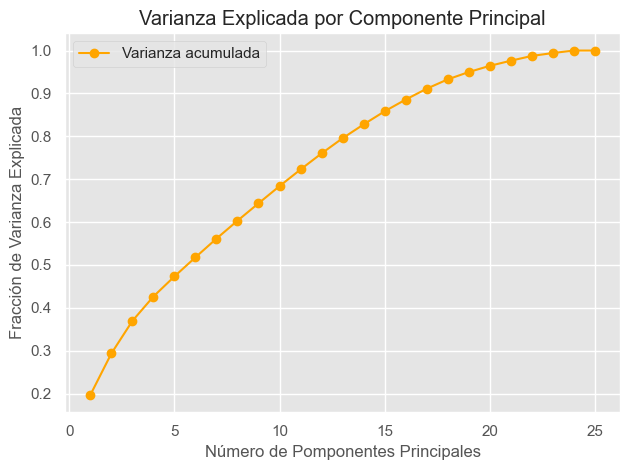

In [ ]:
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='orange', label='Varianza acumulada')
plt.title('Varianza Explicada por Componente Principal')
plt.xlabel('Número de Pomponentes Principales')
plt.ylabel('Fracción de Varianza Explicada')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Verificación de la variable SalePrice en el Proceso**

*Durante la aplicación de PCA no incluyo la variable 'SalePrice' en el conjunto de entrada ya que es la variable que tomé como objetivo, conservandolo para análisis posteriores. Es decir, el PCA se realiza solo sobre los predictores; sin embargo, en análisis de regresión o correlación considero a 'SalePrice' como la variable a explicar dependiente.*

In [45]:
print("'SalePrice' en features:", 'SalePrice' in features)
print("Primeras variables usadas en PCA:", features[:5])
print("Shape X:", X.shape)
print("Shape y:", df_cleaned['SalePrice'].shape)
print("Primeros valores de y (SalePrice):")
print(df_cleaned['SalePrice'].head())

print("Cantidad de componentes PCA:", X_pca.shape[1])
print("Cantidad de features originales (sin SalePrice):", len(features))

'SalePrice' en features: False
Primeras variables usadas en PCA: ['MS SubClass', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built']
Shape X: (2930, 25)
Shape y: (2930,)
Primeros valores de y (SalePrice):
0    215000
1    105000
2    172000
3    244000
4    189900
Name: SalePrice, dtype: int64
Cantidad de componentes PCA: 25
Cantidad de features originales (sin SalePrice): 25


 **El Análisis PCA se hizo correctamente:** sólo sobre las variables predictoras, mientras, *SalePrice*, la reservo como la variable objetivo para el modelado posterior.

In [48]:
# Regresión lineal con datos originales
X_train, X_test, y_train, y_test = train_test_split(X, df_cleaned['SalePrice'], test_size=0.3, random_state=42)
lr = LinearRegression().fit(X_train, y_train)
r2_train_orig = lr.score(X_train, y_train)
r2_test_orig  = lr.score(X_test, y_test)

# Regresión lineal con datos PCA 
pca = PCA(n_components=explica_set).fit(X_train)  
X_train_pca = pca.transform(scaler.transform(X_train))
X_test_pca  = pca.transform(scaler.transform(X_test))
lr_pca = LinearRegression().fit(X_train_pca, y_train)
r2_train_pca = lr_pca.score(X_train_pca, y_train)
r2_test_pca  = lr_pca.score(X_test_pca, y_test)
print(f"R² Entrenamiento (original): {r2_train_orig:.3f}, (PCA): {r2_train_pca:.3f}")
print(f"R² Prueba        (original): {r2_test_orig:.3f},  (PCA): {r2_test_pca:.3f}")


R² Entrenamiento (original): 0.809, (PCA): 0.782
R² Prueba        (original): 0.815,  (PCA): 0.785


Esto muestra que la Regresión Lineal sobre las componentes principales mantiene un desempeño similar (ligeramente inferior), explicando buena parte de la varianza del precio.

Regresión con SVR sobre datos PCA y comparación

In [49]:
best_r2 = -np.inf
best_params = None
for C in [1, 10, 100]:
    for gamma in [0.1, 1, 'scale']:
        svr = SVR(kernel='rbf', C=C, gamma=gamma)
        svr.fit(X_train_pca, y_train)
        r2 = svr.score(X_test_pca, y_test)
        if r2 > best_r2:
            best_r2 = r2
            best_params = (C, gamma)

print("Mejor R² (SVR):", best_r2, "con params C,gamma =", best_params)


Mejor R² (SVR): 0.03852919499900431 con params C,gamma = (100, 0.1)


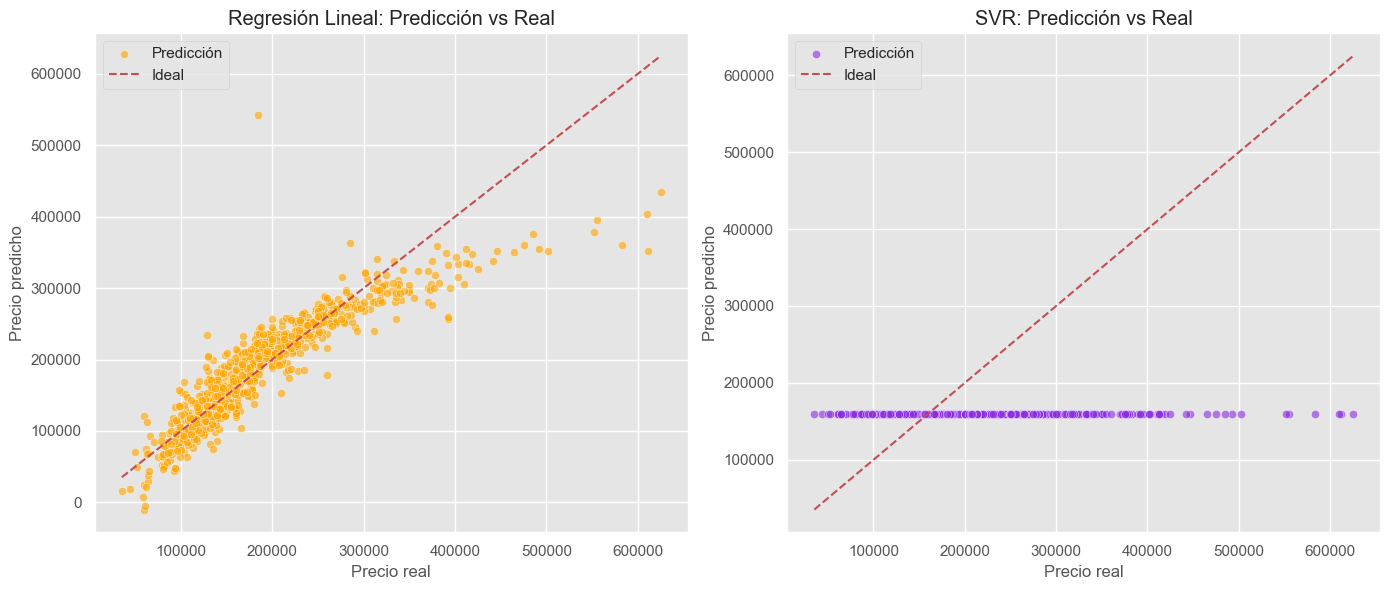

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener predicciones
y_pred_lr = lr.predict(X_test)
y_pred_svr = svr.predict(X_test_pca)

plt.figure(figsize=(14, 6))

# Gráfico 1: Regresión Lineal
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6, color='orange', label='Predicción')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.title('Regresión Lineal: Predicción vs Real')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.legend()
plt.grid(True)

# Gráfico 2: SVR
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_svr, alpha=0.6, color='blueviolet', label='Predicción')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.title('SVR: Predicción vs Real')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


**Conclusión:** Los resultados R² muestran que la Regresión Lineal con datos originales tuvo ventaja sobre el modelo con PCA, y que SVR no superó en rendimiento a la Regresión Lineal.